In [1]:
import os, random, warnings, csv, json as _json, itertools, collections
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import seaborn as sns
from pathlib import Path
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image

warnings.filterwarnings('ignore')
print('Imports OK')

Imports OK


In [2]:
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
print(f'Device: {device}')

Device: cuda


In [3]:
def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

print('seed_everything() defined.')

seed_everything() defined.


In [ ]:

# CONFIG

TRAIN_DATA_ROOT = os.path.expanduser('~/Desktop/george/rocks_spectral_224')
NEW_DATA_ROOT   = os.path.expanduser('~/for_test_data_spectral_224')
RESULTS_DIR     = 'results_fraction_newrock_test'

# Experiment parameters
FRACTIONS  = [0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 1.00]   # fractions of original data to train on
SEEDS      = [7, 42, 123]                                    # runs per fraction (for mean ± std)
EPOCHS     = 20
LR         = 1e-4
WEIGHT_DECAY = 1e-4
BATCH_SIZE = 64
ARCH       = 'resnet18'

# Classes
CLASS_NAMES  = ['S10Granite', 'Holstein_Sandstone', 'Leitendorf_Limestone']
SHORT_NAMES  = ['Granite', 'Sandstone', 'Limestone']
VALID_EXT    = ('.jpg', '.jpeg', '.bmp', '.png')


NEW_ROCK_FOLDERS = {
    'Dunite-Ecologite_2Rocks_1-83Hz':                    (None, 'Dunite [OOD]'),
    'Gneis_1-83Hz':                                      (0,    'Gneis → Granite'),
    'Granite_3SamplesPhilipp_1-83Hz_1':                  (0,    'Gran_Phil_1 → Granite'),
    'Granite_3SamplesPhilipp_1-83Hz_2':                  (0,    'Gran_Phil_2 → Granite'),
    'Limestone_CalcsilicaContaminated_U9_U3_1-83Hz':     (2,    'CalcSil 1.83Hz → Limestone'),
    'Limestone_CalcsilicaContaminated_U9_U3_5-10Hz':     (2,    'CalcSil 5.10Hz → Limestone'),
    'Limestone_Rax_1-83Hz_1':                            (2,    'Lst_Rax_1 → Limestone'),
    'Limestone_Rax_1-83Hz_2':                            (2,    'Lst_Rax_2 → Limestone'),
    'SandstoneNew_1-83Hz':                               (1,    'SstNew → Sandstone'),
}

# Colours per class for plots
CLASS_COLORS = {'S10Granite': '#185FA5', 'Holstein_Sandstone': '#3B6D11', 'Leitendorf_Limestone': '#854F0B'}
FOLDER_COLORS = {
    'Gneis_1-83Hz':                                     '#185FA5',
    'Granite_3SamplesPhilipp_1-83Hz_1':                 '#4a9fd4',
    'Granite_3SamplesPhilipp_1-83Hz_2':                 '#84c3e8',
    'Limestone_CalcsilicaContaminated_U9_U3_1-83Hz':    '#854F0B',
    'Limestone_CalcsilicaContaminated_U9_U3_5-10Hz':    '#c07830',
    'Limestone_Rax_1-83Hz_1':                           '#e0a060',
    'Limestone_Rax_1-83Hz_2':                           '#f0c090',
    'SandstoneNew_1-83Hz':                              '#3B6D11',
    'Dunite-Ecologite_2Rocks_1-83Hz':                   '#888780',
}

# Subdirs
DIR_WEIGHTS  = os.path.join(RESULTS_DIR, 'weights')
DIR_PLOTS    = os.path.join(RESULTS_DIR, 'plots')
DIR_CSV      = os.path.join(RESULTS_DIR, 'csv')
for d in [RESULTS_DIR, DIR_WEIGHTS, DIR_PLOTS, DIR_CSV]:
    os.makedirs(d, exist_ok=True)

_saved_files = []
def save_fig(fig, folder, filename, description, dpi=150):
    path = os.path.join(folder, filename)
    fig.savefig(path, dpi=dpi, bbox_inches='tight')
    _saved_files.append((path, description))
    print(f'[SAVED] {path}')

print('Config ready.')
print(f'  Fractions: {[int(f*100) for f in FRACTIONS]}%')
print(f'  Seeds: {SEEDS}  →  {len(FRACTIONS) * len(SEEDS)} total training runs')
print(f'  New rock folders: {len(NEW_ROCK_FOLDERS)}')

Config ready.
  Fractions: [30, 40, 50, 60, 70, 80, 100]%
  Seeds: [7, 42, 123]  →  21 total training runs
  New rock folders: 9


In [5]:
# TRANSFORMS — identical to all previous notebooks
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.1),
    transforms.RandomGrayscale(p=0.1),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0)),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
    transforms.RandomErasing(p=0.2, scale=(0.02, 0.1)),
])

eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
])

print('Transforms ready.')

Transforms ready.


In [6]:
# DATASET + MODEL

class SpectralImageDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels      = labels
        self.transform   = transform
    def __len__(self): return len(self.image_paths)
    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert('RGB')
        if self.transform: img = self.transform(img)
        return img, self.labels[idx]


def build_model():
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    model.fc = nn.Sequential(
        nn.Dropout(0.3), nn.Linear(model.fc.in_features, len(CLASS_NAMES)))
    return model


print('Dataset + model helpers ready.')

Dataset + model helpers ready.


In [ ]:
# LOAD ALL ORIGINAL DATA ONCE

def load_original_all(root):
    paths, labels = [], []
    for folder in sorted(os.listdir(root)):
        fpath = os.path.join(root, folder)
        if not os.path.isdir(fpath): continue
        label = None
        for ci, cls in enumerate(CLASS_NAMES):
            if cls in folder:
                label = ci; break
        if label is None: continue
        imgs = sorted([
            str(f) for f in Path(fpath).iterdir()
            if f.suffix.lower() in VALID_EXT])
        paths.extend(imgs)
        labels.extend([label] * len(imgs))
        print(f'  {folder}: {len(imgs)} images → {CLASS_NAMES[label]}')
    return paths, labels


print('Loading original data...')
all_orig_paths, all_orig_labels = load_original_all(TRAIN_DATA_ROOT)
print(f'Total original images: {len(all_orig_paths)}')
for ci, cls in enumerate(CLASS_NAMES):
    n = sum(1 for l in all_orig_labels if l == ci)
    print(f'  {cls}: {n}')

Loading original data...
  Holstein_Sandstone_1-83Hz_Spectral: 4000 images → Holstein_Sandstone
  Holstein_Sandstone_5-10Hz_Spectral: 4000 images → Holstein_Sandstone
  Leitendorf_Limestone_1-83Hz_Spectral: 4076 images → Leitendorf_Limestone
  Leitendorf_Limestone_5-10Hz_Spectral: 4035 images → Leitendorf_Limestone
  S10Granite_1-83Hz_Spectral: 4003 images → S10Granite
  S10Granite_5-10Hz_Spectral: 4155 images → S10Granite
Total original images: 24269
  S10Granite: 8158
  Holstein_Sandstone: 8000
  Leitendorf_Limestone: 8111


In [ ]:
# LOAD NEW ROCK FOLDERS

new_rock_data = {}  

for folder_name, (expected_label, display) in NEW_ROCK_FOLDERS.items():
    folder_path = os.path.join(NEW_DATA_ROOT, folder_name)
    if not os.path.isdir(folder_path):
        print(f'  [MISSING] {folder_name}')
        continue
    imgs = sorted([
        str(f) for f in Path(folder_path).iterdir()
        if f.suffix.lower() in VALID_EXT])
    new_rock_data[folder_name] = {
        'paths':   imgs,
        'label':   expected_label,
        'display': display,
        'n':       len(imgs),
    }
    print(f'  {display}: {len(imgs)} images')

print(f'\nNew rock folders loaded: {len(new_rock_data)}')

  Dunite [OOD]: 500 images
  Gneis → Granite: 500 images
  Gran_Phil_1 → Granite: 1000 images
  Gran_Phil_2 → Granite: 490 images
  CalcSil 1.83Hz → Limestone: 1000 images
  CalcSil 5.10Hz → Limestone: 1000 images
  Lst_Rax_1 → Limestone: 25 images
  Lst_Rax_2 → Limestone: 20 images
  SstNew → Sandstone: 21 images

New rock folders loaded: 9


[SAVED] results_fraction_newrock_test/plots/DA-01_data_overview.png


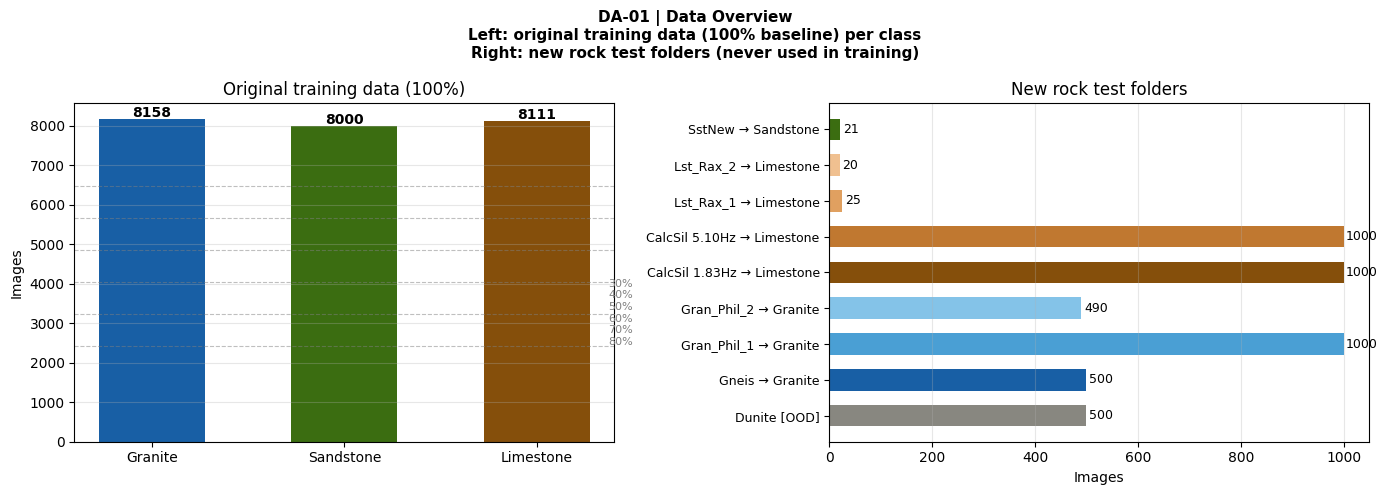

In [9]:
# DA-01  Dataset composition overview
# Shows how many original images exist per class (100% baseline)
# and how many images are in each new test folder.

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    'DA-01 | Data Overview\n'
    'Left: original training data (100% baseline) per class\n'
    'Right: new rock test folders (never used in training)',
    fontsize=11, fontweight='bold')

# Left — original per class
class_counts = [sum(1 for l in all_orig_labels if l == ci) for ci in range(3)]
colors = [CLASS_COLORS[c] for c in CLASS_NAMES]
bars = axes[0].bar(SHORT_NAMES, class_counts, color=colors, width=0.55)
for bar, count in zip(bars, class_counts):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                  str(count), ha='center', fontsize=10, fontweight='bold')
axes[0].set_ylabel('Images'); axes[0].set_title('Original training data (100%)')
axes[0].grid(True, axis='y', alpha=0.3)

# Also draw fraction lines
for frac in FRACTIONS[:-1]:
    n_approx = int(sum(class_counts) * frac)
    axes[0].axhline(n_approx / 3, color='gray', ls='--', lw=0.8, alpha=0.5)
axes[0].text(2.5, min(class_counts)*0.3,
              '\n'.join([f'{int(f*100)}%' for f in FRACTIONS[:-1]]),
              fontsize=8, color='gray', ha='right', va='bottom')

# Right — new test folders
folder_names  = list(new_rock_data.keys())
folder_counts = [new_rock_data[f]['n'] for f in folder_names]
folder_colors = [FOLDER_COLORS.get(f, '#888') for f in folder_names]
folder_labels = [new_rock_data[f]['display'] for f in folder_names]

y = np.arange(len(folder_names))
bars2 = axes[1].barh(y, folder_counts, color=folder_colors, height=0.6)
for bar, count in zip(bars2, folder_counts):
    axes[1].text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
                  str(count), va='center', fontsize=9)
axes[1].set_yticks(y)
axes[1].set_yticklabels(folder_labels, fontsize=9)
axes[1].set_xlabel('Images')
axes[1].set_title('New rock test folders')
axes[1].grid(True, axis='x', alpha=0.3)

plt.tight_layout()
save_fig(fig, DIR_PLOTS, 'DA-01_data_overview.png', 'Original vs new rock data overview')
plt.show()

In [10]:
# CORE TRAINING FUNCTION

def train_one_run(fraction, seed):
    """
    Train ResNet-18 on `fraction` of original data.
    Returns trained model (in eval mode).
    Saves weights to DIR_WEIGHTS to avoid re-running.
    """
    weight_path = os.path.join(
        DIR_WEIGHTS, f'resnet18_frac{int(fraction*100):03d}_seed{seed}.pth')

    if os.path.exists(weight_path):
        model = build_model().to(device)
        model.load_state_dict(torch.load(weight_path, map_location=device,
                                          weights_only=True))
        model.eval()
        return model

    seed_everything(seed)

    # Sample fraction of original data, stratified per class
    if fraction < 1.0:
        tr_paths, _, tr_labels, _ = train_test_split(
            all_orig_paths, all_orig_labels,
            train_size=fraction, stratify=all_orig_labels, random_state=seed)
    else:
        tr_paths, tr_labels = all_orig_paths, all_orig_labels

    n_per_class = {ci: sum(1 for l in tr_labels if l == ci) for ci in range(3)}

    ds  = SpectralImageDataset(tr_paths, tr_labels, train_transform)
    nw  = min(4, os.cpu_count() or 1)
    pin = (device.type == 'cuda')
    ldr = DataLoader(ds, BATCH_SIZE, shuffle=True,
                      num_workers=nw, pin_memory=pin, persistent_workers=(nw > 0))

    model     = build_model().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=0.5, patience=3)
    warmup    = torch.optim.lr_scheduler.LinearLR(
        optimizer, start_factor=0.1, end_factor=1.0, total_iters=2)
    criterion = nn.CrossEntropyLoss()
    use_amp   = (device.type == 'cuda')
    scaler    = torch.amp.GradScaler('cuda') if use_amp else None

    best_tr_acc = -1.0

    for epoch in range(EPOCHS):
        model.train()
        ep_acc = []
        for Xb, yb in ldr:
            Xb, yb = Xb.to(device), yb.to(device)
            optimizer.zero_grad()
            if use_amp:
                with torch.amp.autocast('cuda'):
                    out  = model(Xb); loss = criterion(out, yb)
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), 0.5)
                scaler.step(optimizer); scaler.update()
            else:
                out  = model(Xb); loss = criterion(out, yb)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 0.5)
                optimizer.step()
            ep_acc.append((out.argmax(1) == yb).float().mean().item())

        tr_acc = float(np.mean(ep_acc))
        if epoch < 2: warmup.step()
        else:         scheduler.step(tr_acc)
        if tr_acc > best_tr_acc:
            best_tr_acc = tr_acc
            torch.save(model.state_dict(), weight_path)

    # Reload best
    model.load_state_dict(torch.load(weight_path, map_location=device, weights_only=True))
    model.eval()

    del optimizer, criterion, ds, ldr
    if scaler: del scaler
    torch.cuda.empty_cache()

    return model


print('train_one_run() defined.')

train_one_run() defined.


In [11]:
# EVALUATION FUNCTION — run model on a new rock folder

def evaluate_on_folder(model, folder_name):
    """
    Run model on a new rock folder.
    Returns dict with accuracy (None for OOD folders), top predicted class,
    mean confidence, and per-class mean probabilities.
    """
    d     = new_rock_data[folder_name]
    nw    = min(4, os.cpu_count() or 1)
    pin   = (device.type == 'cuda')
    ds    = SpectralImageDataset(d['paths'],
                                  [0] * d['n'],   # dummy labels
                                  eval_transform)
    ldr   = DataLoader(ds, BATCH_SIZE, shuffle=False,
                        num_workers=nw, pin_memory=pin, persistent_workers=(nw > 0))
    all_probs = []
    with torch.no_grad():
        for Xb, _ in ldr:
            probs = torch.softmax(model(Xb.to(device)), dim=1).cpu().numpy()
            all_probs.extend(probs.tolist())

    all_probs = np.array(all_probs)
    preds     = all_probs.argmax(axis=1)
    confs     = all_probs.max(axis=1)
    top_pred  = int(np.bincount(preds).argmax())
    mean_conf = float(confs.mean())
    mean_prob = all_probs.mean(axis=0).tolist()

    accuracy = None
    if d['label'] is not None:
        accuracy = float(np.mean(preds == d['label'])) * 100

    return dict(accuracy=accuracy, top_pred=top_pred,
                mean_conf=mean_conf, mean_prob=mean_prob,
                n=d['n'])


print('evaluate_on_folder() defined.')

evaluate_on_folder() defined.


In [ ]:
# MAIN EXPERIMENT LOOP
# For each (fraction, seed) pair:
#   1. Train (or load cached weights)
#   2. Evaluate on every new rock folder
#   3. Store results

# results[fraction][folder_name][seed] = eval_dict
results = {f: {fn: {} for fn in new_rock_data} for f in FRACTIONS}

total_runs = len(FRACTIONS) * len(SEEDS)
run_num    = 0

for fraction in FRACTIONS:
    for seed in SEEDS:
        run_num += 1
        pct = int(fraction * 100)
        print(f'\n[{run_num}/{total_runs}] fraction={pct}%  seed={seed}')

        # Count training images for this fraction
        n_train_approx = int(len(all_orig_paths) * fraction)
        print(f'  Training on ~{n_train_approx} images...')

        model = train_one_run(fraction, seed)

        # Evaluate on every new folder
        for folder_name in new_rock_data:
            res = evaluate_on_folder(model, folder_name)
            results[fraction][folder_name][seed] = res
            display = new_rock_data[folder_name]['display']
            acc_str = f"{res['accuracy']:.1f}%" if res['accuracy'] is not None else 'OOD'
            print(f'    {display:<35}  acc={acc_str:<8}  top={CLASS_NAMES[res["top_pred"]].split("_")[0]}')

        del model
        torch.cuda.empty_cache()

print('\nAll runs complete.')


[1/21] fraction=30%  seed=7
  Training on ~7280 images...


    Dunite [OOD]                         acc=OOD       top=Leitendorf
    Gneis → Granite                      acc=92.8%     top=S10Granite
    Gran_Phil_1 → Granite                acc=0.0%      top=Leitendorf
    Gran_Phil_2 → Granite                acc=0.0%      top=Leitendorf
    CalcSil 1.83Hz → Limestone           acc=20.5%     top=Holstein
    CalcSil 5.10Hz → Limestone           acc=17.5%     top=Holstein
    Lst_Rax_1 → Limestone                acc=96.0%     top=Leitendorf
    Lst_Rax_2 → Limestone                acc=90.0%     top=Leitendorf
    SstNew → Sandstone                   acc=9.5%      top=Leitendorf

[2/21] fraction=30%  seed=42
  Training on ~7280 images...
    Dunite [OOD]                         acc=OOD       top=Leitendorf
    Gneis → Granite                      acc=77.0%     top=S10Granite
    Gran_Phil_1 → Granite                acc=0.0%      top=Leitendorf
    Gran_Phil_2 → Granite                acc=0.0%      top=Leitendorf
    CalcSil 1.83Hz → Limestone    

KeyboardInterrupt: 

In [ ]:
# AGGREGATE RESULTS

agg = {}  

for folder_name in new_rock_data:
    agg[folder_name] = {}
    for fraction in FRACTIONS:
        vals = [
            results[fraction][folder_name][seed]['accuracy']
            for seed in SEEDS
            if results[fraction][folder_name][seed]['accuracy'] is not None
        ]
        if vals:
            agg[folder_name][fraction] = {
                'mean': float(np.mean(vals)),
                'std':  float(np.std(vals)),
                'vals': vals,
            }

# Save to CSV
csv_path = os.path.join(DIR_CSV, 'fraction_accuracy_all_folders.csv')
with open(csv_path, 'w', newline='') as f:
    w = csv.writer(f)
    header = ['folder', 'display', 'fraction_pct']
    for seed in SEEDS: header.append(f'acc_seed{seed}')
    header += ['mean_acc', 'std_acc']
    w.writerow(header)
    for folder_name in new_rock_data:
        for fraction in FRACTIONS:
            if fraction not in agg[folder_name]: continue
            d = agg[folder_name][fraction]
            row = [folder_name, new_rock_data[folder_name]['display'], int(fraction*100)]
            for seed in SEEDS:
                v = results[fraction][folder_name][seed]['accuracy']
                row.append(round(v, 2) if v is not None else '')
            row += [round(d['mean'], 2), round(d['std'], 2)]
            w.writerow(row)

_saved_files.append((csv_path, 'Per-folder accuracy at every fraction × seed'))
print(f'[SAVED] {csv_path}')
print('\nSummary (mean accuracy across seeds at each fraction):')
print(f'{"Folder":<40}  ' + '  '.join(f"{int(f*100)}%" for f in FRACTIONS))
print('-' * 100)
for folder_name, d_display in [(k, v['display']) for k, v in new_rock_data.items()]:
    if agg[folder_name]:
        row = f'{d_display:<40}  '
        for fraction in FRACTIONS:
            if fraction in agg[folder_name]:
                row += f"{agg[folder_name][fraction]['mean']:>6.1f}%  "
            else:
                row += f"{'OOD':>6}   "
        print(row)

[SAVED] results_fraction_newrock_test/csv/fraction_accuracy_all_folders.csv

Summary (mean accuracy across seeds at each fraction):
Folder                                    30%  40%  50%  60%  70%  80%  100%
----------------------------------------------------------------------------------------------------
Gneis → Granite                             79.1%    75.2%    66.7%    61.0%    81.6%    63.7%    69.7%  
Gran_Phil_1 → Granite                        0.0%     0.0%     0.0%     0.0%     0.0%     0.0%     0.0%  
Gran_Phil_2 → Granite                        0.0%     0.0%     0.0%     0.0%     0.0%     0.0%     0.0%  
CalcSil 1.83Hz → Limestone                  24.3%    26.1%    25.9%    33.1%    29.7%    28.3%    26.0%  
CalcSil 5.10Hz → Limestone                  21.8%    24.8%    24.8%    33.1%    29.8%    28.6%    25.1%  
Lst_Rax_1 → Limestone                       98.7%   100.0%   100.0%   100.0%   100.0%   100.0%   100.0%  
Lst_Rax_2 → Limestone                       93.3%    9

[SAVED] results_fraction_newrock_test/plots/RES-01_accuracy_vs_fraction.png


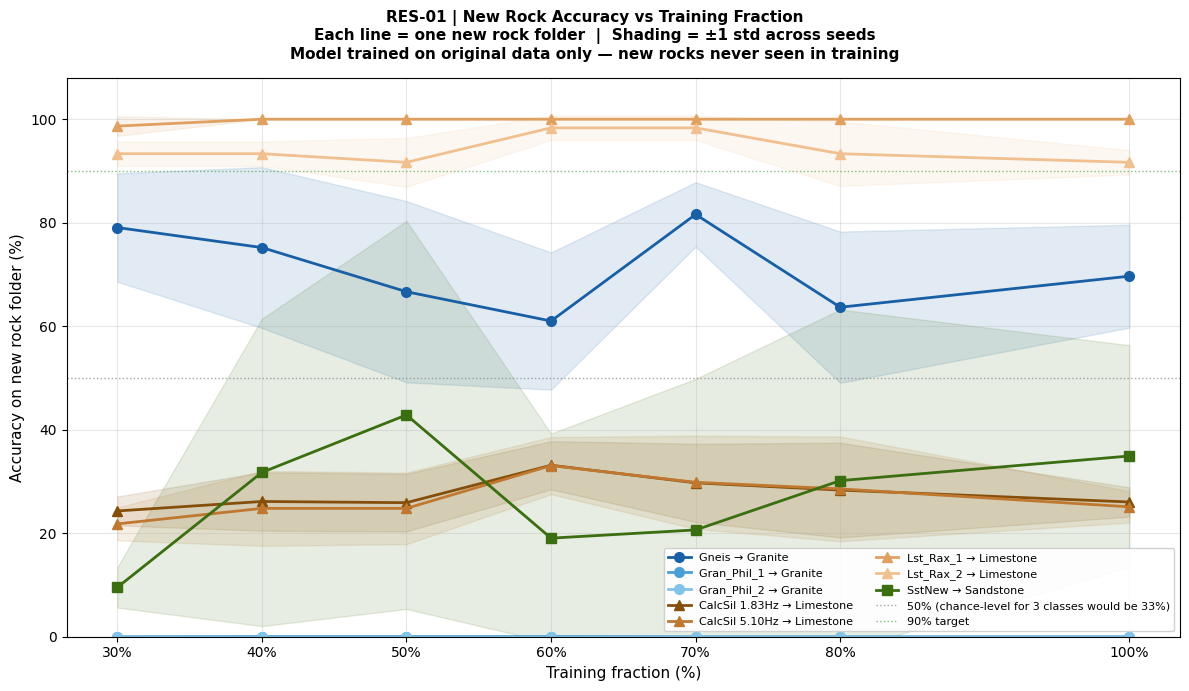

In [ ]:
# RES-01  Accuracy vs training fraction — one line per new rock folder
# The main result. Shows how each new rock folder responds to more/less training data.
# Expected patterns:
#   - Flat high line: rock already classifiable even with 30% data
#   - Rising line: more data helps generalisation
#   - Flat low line: no amount of original data helps (spectral mismatch)

pct_values = [int(f*100) for f in FRACTIONS]

# Separate OOD folder from labelled folders
labelled_folders = [fn for fn in new_rock_data if new_rock_data[fn]['label'] is not None]

fig, ax = plt.subplots(figsize=(12, 7))
fig.suptitle(
    'RES-01 | New Rock Accuracy vs Training Fraction\n'
    'Each line = one new rock folder  |  Shading = ±1 std across seeds\n'
    'Model trained on original data only — new rocks never seen in training',
    fontsize=11, fontweight='bold')

# Group by expected class
class_markers = {0: 'o', 1: 's', 2: '^'}

for folder_name in labelled_folders:
    d     = new_rock_data[folder_name]
    color = FOLDER_COLORS.get(folder_name, '#888')
    xs, ys_mean, ys_std = [], [], []
    for fraction in FRACTIONS:
        if fraction not in agg[folder_name]: continue
        xs.append(int(fraction*100))
        ys_mean.append(agg[folder_name][fraction]['mean'])
        ys_std.append(agg[folder_name][fraction]['std'])
    xs      = np.array(xs)
    ys_mean = np.array(ys_mean)
    ys_std  = np.array(ys_std)
    marker  = class_markers.get(d['label'], 'x')
    ax.plot(xs, ys_mean, '-', color=color, marker=marker,
             ms=7, lw=2, label=d['display'])
    ax.fill_between(xs, ys_mean - ys_std, ys_mean + ys_std,
                     color=color, alpha=0.12)

# Reference lines
ax.axhline(50, color='gray', ls=':', lw=1.0, alpha=0.7, label='50% (chance-level for 3 classes would be 33%)')
ax.axhline(90, color='green', ls=':', lw=1.0, alpha=0.5, label='90% target')

ax.set_xlabel('Training fraction (%)', fontsize=11)
ax.set_ylabel('Accuracy on new rock folder (%)', fontsize=11)
ax.set_xticks(pct_values)
ax.set_xticklabels([f'{p}%' for p in pct_values])
ax.set_ylim(0, 108)
ax.legend(fontsize=8, loc='lower right', ncol=2, framealpha=0.9)
ax.grid(True, alpha=0.3)

# Class legend in upper left
for ci, (cls, marker) in enumerate(zip(SHORT_NAMES, ['o','s','^'])):
    ax.plot([], [], marker=marker, color='black', ms=6, lw=0,
             label=f'{cls} expected')

plt.tight_layout()
save_fig(fig, DIR_PLOTS, 'RES-01_accuracy_vs_fraction.png',
    'Main result: new rock accuracy vs training fraction')
plt.show()

[SAVED] results_fraction_newrock_test/plots/RES-02_heatmap_fraction_folder.png


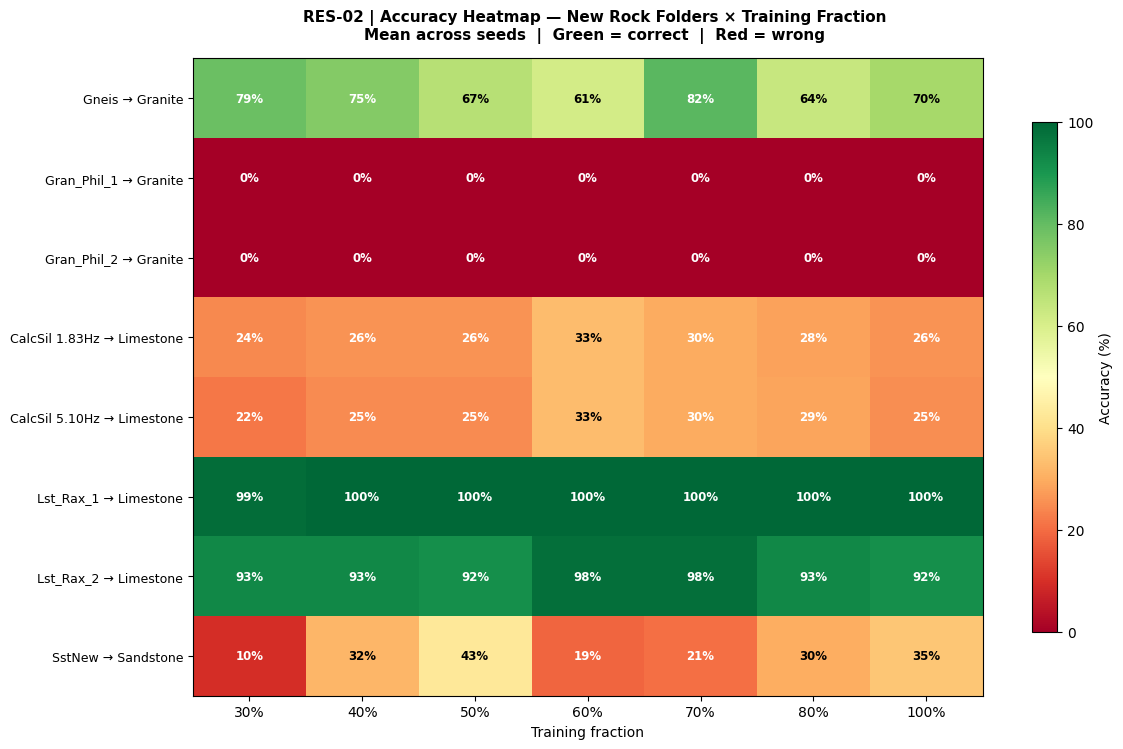

In [ ]:
# RES-02  Heatmap — fraction × folder accuracy
# Quick overview of the full result matrix.
# Green = correct  |  Red = wrong  |  Each cell = mean accuracy across seeds.

folder_order   = labelled_folders
folder_labels_ordered = [new_rock_data[fn]['display'] for fn in folder_order]
fraction_labels = [f'{int(f*100)}%' for f in FRACTIONS]

matrix = np.full((len(folder_order), len(FRACTIONS)), np.nan)
for ri, folder_name in enumerate(folder_order):
    for ci, fraction in enumerate(FRACTIONS):
        if fraction in agg[folder_name]:
            matrix[ri, ci] = agg[folder_name][fraction]['mean']

fig, ax = plt.subplots(figsize=(12, max(5, len(folder_order) * 0.7 + 2)))
fig.suptitle(
    'RES-02 | Accuracy Heatmap — New Rock Folders × Training Fraction\n'
    'Mean across seeds  |  Green = correct  |  Red = wrong',
    fontsize=11, fontweight='bold')

im = ax.imshow(matrix, aspect='auto', cmap='RdYlGn', vmin=0, vmax=100)
plt.colorbar(im, ax=ax, label='Accuracy (%)', shrink=0.8)

ax.set_xticks(range(len(FRACTIONS)))
ax.set_xticklabels(fraction_labels, fontsize=10)
ax.set_yticks(range(len(folder_order)))
ax.set_yticklabels(folder_labels_ordered, fontsize=9)
ax.set_xlabel('Training fraction')

for ri in range(matrix.shape[0]):
    for ci in range(matrix.shape[1]):
        if not np.isnan(matrix[ri, ci]):
            val = matrix[ri, ci]
            color = 'white' if val < 30 or val > 75 else 'black'
            ax.text(ci, ri, f'{val:.0f}%', ha='center', va='center',
                     fontsize=8.5, color=color, fontweight='bold')

plt.tight_layout()
save_fig(fig, DIR_PLOTS, 'RES-02_heatmap_fraction_folder.png',
    'Accuracy heatmap: fraction × new rock folder')
plt.show()

[SAVED] results_fraction_newrock_test/plots/RES-03_per_class_accuracy.png


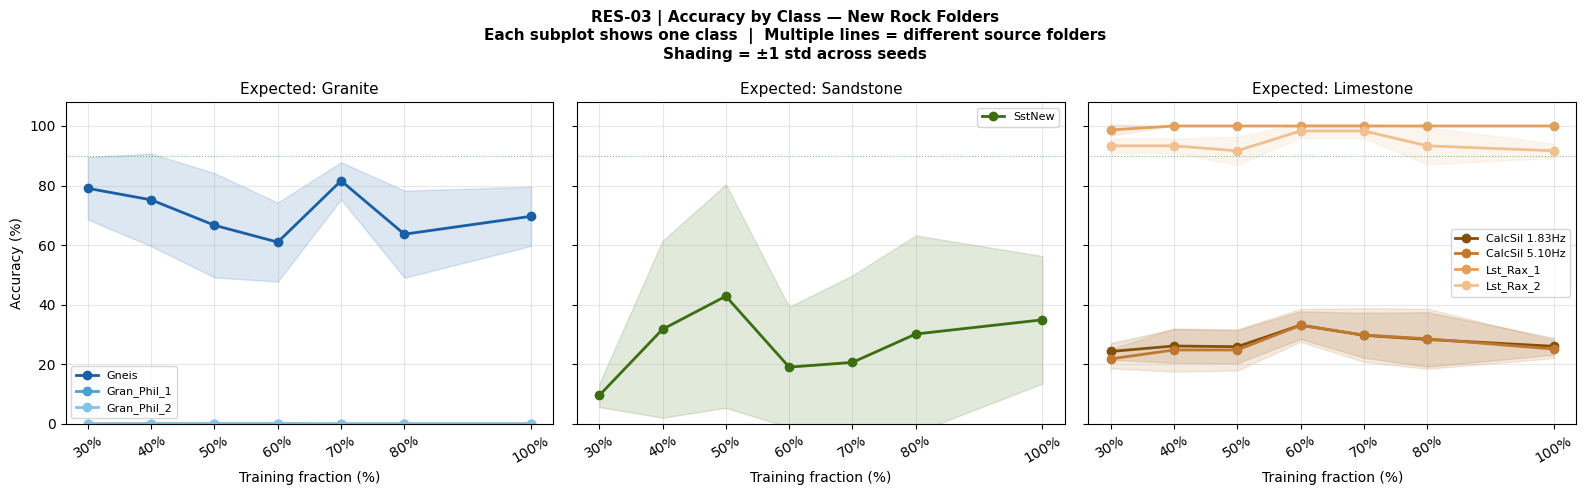

In [ ]:
# RES-03  Per-class grouped accuracy at each fraction
# Shows granite folders together, sandstone together, limestone together.
# Easier to see if one class consistently generalises better than others.

class_folders = {ci: [] for ci in range(3)}
for fn in labelled_folders:
    class_folders[new_rock_data[fn]['label']].append(fn)

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
fig.suptitle(
    'RES-03 | Accuracy by Class — New Rock Folders\n'
    'Each subplot shows one class  |  Multiple lines = different source folders\n'
    'Shading = ±1 std across seeds',
    fontsize=11, fontweight='bold')

for ci, (ax, cls_name, short) in enumerate(zip(axes, CLASS_NAMES, SHORT_NAMES)):
    ax.set_title(f'Expected: {short}', fontsize=11)
    ax.set_xlabel('Training fraction (%)')
    if ci == 0: ax.set_ylabel('Accuracy (%)')
    ax.set_xticks(pct_values)
    ax.set_xticklabels([f'{p}%' for p in pct_values], rotation=30)
    ax.set_ylim(0, 108)
    ax.axhline(90, color='green', ls=':', lw=0.8, alpha=0.5)
    ax.grid(True, alpha=0.3)

    for folder_name in class_folders[ci]:
        d     = new_rock_data[folder_name]
        color = FOLDER_COLORS.get(folder_name, '#888')
        xs, ys_mean, ys_std = [], [], []
        for fraction in FRACTIONS:
            if fraction not in agg[folder_name]: continue
            xs.append(int(fraction*100))
            ys_mean.append(agg[folder_name][fraction]['mean'])
            ys_std.append(agg[folder_name][fraction]['std'])
        xs, ys_mean, ys_std = np.array(xs), np.array(ys_mean), np.array(ys_std)
        ax.plot(xs, ys_mean, '-o', color=color, ms=6, lw=2,
                 label=d['display'].split('→')[0].strip())
        ax.fill_between(xs, ys_mean - ys_std, ys_mean + ys_std,
                         color=color, alpha=0.15)
    ax.legend(fontsize=8)

plt.tight_layout()
save_fig(fig, DIR_PLOTS, 'RES-03_per_class_accuracy.png',
    'Per-class accuracy vs fraction for new rock folders')
plt.show()

[SAVED] results_fraction_newrock_test/plots/RES-04_confidence_by_folder.png


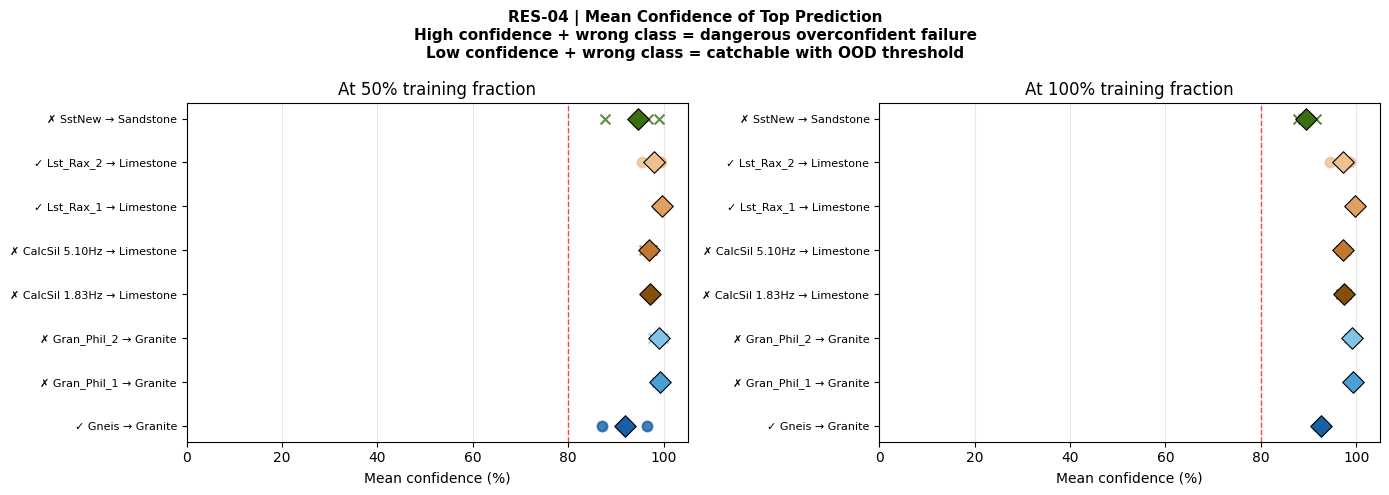

In [ ]:
# RES-04  Mean confidence of top prediction at each fraction
# Even if accuracy is low, confidence shows HOW WRONG the model is.
# High confidence + wrong class = overconfident failure (the dangerous case)
# Low confidence + wrong class = uncertain failure (better — can be caught by threshold)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    'RES-04 | Mean Confidence of Top Prediction\n'
    'High confidence + wrong class = dangerous overconfident failure\n'
    'Low confidence + wrong class = catchable with OOD threshold',
    fontsize=11, fontweight='bold')

# Left: confidence for correctly predicted folders
# Right: confidence for incorrectly predicted folders
# Split at 100% fraction for simplicity

for ax_idx, fraction_to_plot in enumerate([0.50, 1.00]):
    ax = axes[ax_idx]
    pct = int(fraction_to_plot * 100)
    ax.set_title(f'At {pct}% training fraction')
    ax.set_xlabel('Mean confidence (%)')
    ax.axvline(80, color='red', ls='--', lw=1.0, alpha=0.7, label='0.80 threshold')
    ax.grid(True, axis='x', alpha=0.3)

    y_pos = 0
    yticks, ylabels = [], []
    for folder_name in labelled_folders:
        if fraction_to_plot not in results or fraction_to_plot not in agg[folder_name]:
            continue
        mean_confs = [
            results[fraction_to_plot][folder_name][s]['mean_conf'] * 100
            for s in SEEDS]
        mean_acc = agg[folder_name][fraction_to_plot]['mean']
        is_correct = mean_acc >= 50
        color  = FOLDER_COLORS.get(folder_name, '#888')
        marker = 'o' if is_correct else 'x'
        for conf in mean_confs:
            ax.scatter(conf, y_pos, color=color, marker=marker, s=50, zorder=3,
                        alpha=0.8, linewidths=1.5)
        ax.scatter(np.mean(mean_confs), y_pos, color=color, s=120,
                    marker='D', zorder=4, edgecolors='black', linewidths=0.8)
        d = new_rock_data[folder_name]
        yticks.append(y_pos)
        status = '✓' if is_correct else '✗'
        ylabels.append(f"{status} {d['display']}")
        y_pos += 1

    ax.set_yticks(yticks)
    ax.set_yticklabels(ylabels, fontsize=8)
    ax.set_xlim(0, 105)

plt.tight_layout()
save_fig(fig, DIR_PLOTS, 'RES-04_confidence_by_folder.png',
    'Mean confidence of top prediction at 50% and 100% training fraction')
plt.show()

In [ ]:
# FINAL SUMMARY TABLE
print('=' * 90)
print('FINAL SUMMARY — Fraction Study × New Rock Test')
print('=' * 90)
print(f'Architecture: {ARCH}  |  Epochs: {EPOCHS}  |  Seeds per fraction: {len(SEEDS)}')
print(f'Training data: original 3 classes only  |  Test: new rock folders (never seen)')
print()
print(f'{"Folder":<42} {"Expected":>10}  |', end='')
for f in FRACTIONS: print(f' {int(f*100)}%', end='')
print()
print('-' * 90)

for folder_name in labelled_folders:
    d   = new_rock_data[folder_name]
    exp = CLASS_NAMES[d['label']].split('_')[0]
    print(f'{d["display"]:<42} {exp:>10}  |', end='')
    for f in FRACTIONS:
        if f in agg[folder_name]:
            mean = agg[folder_name][f]['mean']
            mark = '+' if mean >= 70 else ('-' if mean < 40 else '~')
            print(f' {mean:>3.0f}{mark}', end='')
        else:
            print(f'  --', end='')
    print()

print()
print('Legend: + = >70%  ~ = 40-70%  - = <40%')
print()

# Key finding: which folders benefit from more data?
print('Folders that improve with more training data:')
for folder_name in labelled_folders:
    fracs = [f for f in FRACTIONS if f in agg[folder_name]]
    if len(fracs) < 2: continue
    low   = agg[folder_name][fracs[0]]['mean']
    high  = agg[folder_name][fracs[-1]]['mean']
    delta = high - low
    if abs(delta) > 5:
        direction = 'improves' if delta > 0 else 'degrades'
        print(f'  {new_rock_data[folder_name]["display"]}: {direction} by {abs(delta):.1f}pp '
              f'({low:.0f}% → {high:.0f}%)')

print()
print('Folders that do NOT benefit (flat or random regardless of fraction):')
for folder_name in labelled_folders:
    fracs = [f for f in FRACTIONS if f in agg[folder_name]]
    if len(fracs) < 2: continue
    vals  = [agg[folder_name][f]['mean'] for f in fracs]
    spread = max(vals) - min(vals)
    if spread <= 5:
        print(f'  {new_rock_data[folder_name]["display"]}: flat at ~{np.mean(vals):.0f}%')

print('=' * 90)

FINAL SUMMARY — Fraction Study × New Rock Test
Architecture: resnet18  |  Epochs: 20  |  Seeds per fraction: 3
Training data: original 3 classes only  |  Test: new rock folders (never seen)

Folder                                       Expected  | 30% 40% 50% 60% 70% 80% 100%
------------------------------------------------------------------------------------------
Gneis → Granite                            S10Granite  |  79+  75+  67~  61~  82+  64~  70~
Gran_Phil_1 → Granite                      S10Granite  |   0-   0-   0-   0-   0-   0-   0-
Gran_Phil_2 → Granite                      S10Granite  |   0-   0-   0-   0-   0-   0-   0-
CalcSil 1.83Hz → Limestone                 Leitendorf  |  24-  26-  26-  33-  30-  28-  26-
CalcSil 5.10Hz → Limestone                 Leitendorf  |  22-  25-  25-  33-  30-  29-  25-
Lst_Rax_1 → Limestone                      Leitendorf  |  99+ 100+ 100+ 100+ 100+ 100+ 100+
Lst_Rax_2 → Limestone                      Leitendorf  |  93+  93+  92+  98+  98

In [ ]:
# Save results index
index_path = os.path.join(RESULTS_DIR, 'RESULTS_INDEX.txt')
with open(index_path, 'w') as f:
    f.write('RESULTS INDEX — rock_classifier_fraction_newrock_test\n')
    f.write('=' * 80 + '\n')
    f.write(f'ARCH={ARCH}  EPOCHS={EPOCHS}  LR={LR}\n')
    f.write(f'FRACTIONS={[int(x*100) for x in FRACTIONS]}%\n')
    f.write(f'SEEDS={SEEDS}  (mean±std per cell)\n')
    f.write(f'Total training runs: {len(FRACTIONS)*len(SEEDS)}\n')
    f.write('\nFILES\n' + '-'*80 + '\n')
    for path, desc in _saved_files:
        f.write(f'  {os.path.basename(path)}\n    {desc}\n\n')

print(f'[SAVED] {index_path}')
print(f'Total files saved: {len(_saved_files)}')

[SAVED] results_fraction_newrock_test/RESULTS_INDEX.txt
Total files saved: 6
